# Deep Analysis: hipótesis de complejidad y costo

Este notebook valida estadísticamente las hipótesis:

1. La complejidad aumenta con más tiempo.
2. La complejidad aumenta con más requisitos y más formatos.
3. La complejidad disminuye con mayor digitalización.

Además, estima qué variables se asocian con `TraCosto` usando p-values de un modelo de regresión logística.

> Nota metodológica: como no existe una etiqueta observada de "complejidad", se usa un índice latente (PCA) para el contraste exploratorio.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.formula.api as smf

plt.style.use('seaborn-v0_8-whitegrid')
ALPHA = 0.05

In [4]:
# Carga de datos
root = Path.cwd().parent
base = pd.read_csv(root / 'Effor_index_MASTER.csv')
vt = pd.read_csv(root / 'visitas_totales.csv')[['Idtram', 'visitas_totales']]
vr = pd.read_csv(root / 'visitas_ruts.csv')[['Idtram', 'Visitas RUTS']]

df = (
    base.merge(vt, on='Idtram', how='left')
        .merge(vr, on='Idtram', how='left')
        .dropna(subset=['Idtram'])
        .copy()
)

print('Filas, columnas:', df.shape)
print('TraCosto:', df['TraCosto'].value_counts().to_dict())

Filas, columnas: (665, 16)
TraCosto: {'VERDADERO': 465, 'FALSO': 200}


In [6]:
# Preprocesamiento
df['digitalizacion_num'] = pd.to_numeric(
    df['nivel_digitalizacion'].astype(str).str.extract(r'([0-9]+(?:\.[0-9]+)?)', expand=False),
    errors='coerce'
)

df['TraCosto_bin'] = (df['TraCosto'].str.upper() == 'VERDADERO').astype(int)
df['log_tiempo'] = np.log1p(df['Tiempo_en_minutos'].clip(lower=0))
df['log_visitas_totales'] = np.log1p(df['visitas_totales'].clip(lower=0))
df['log_visitas_ruts'] = np.log1p(df['Visitas RUTS'].clip(lower=0))

num_cols = [
    'Tiempo_en_minutos', 'CONTEO_NETO', 'N_FORMATOS_FINAL',
    'digitalizacion_num', 'Porcentaje_Efectividad',
    'log_tiempo', 'log_visitas_totales', 'log_visitas_ruts'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['TraPersona'] = df['TraPersona'].fillna(df['TraPersona'].mode(dropna=True)[0])

print('Nulos restantes:', int(df.isna().sum().sum()))

Nulos restantes: 366


## Índice de complejidad (PCA)
Se usa la primera componente principal sobre `log_tiempo`, `CONTEO_NETO`, `N_FORMATOS_FINAL`, `digitalizacion_num`.


In [7]:
pca_features = ['log_tiempo', 'CONTEO_NETO', 'N_FORMATOS_FINAL', 'digitalizacion_num']
X = df[pca_features].copy()
Z = StandardScaler().fit_transform(X)

pca = PCA(n_components=1, random_state=42)
complexity_score = pca.fit_transform(Z).ravel()
loadings = pd.Series(pca.components_[0], index=pca_features, name='loading_pc1')

# Orientamos PC1 para que mayor score represente mayor carga temporal
if loadings['log_tiempo'] < 0:
    complexity_score = -complexity_score
    loadings = -loadings

df['complexity_score'] = complexity_score

print('Varianza explicada por PC1:', round(float(pca.explained_variance_ratio_[0]), 4))
loadings

Varianza explicada por PC1: 0.3465


log_tiempo            0.056262
CONTEO_NETO           0.692972
N_FORMATOS_FINAL      0.673851
digitalizacion_num    0.250096
Name: loading_pc1, dtype: float64

## Contraste de hipótesis (Spearman + p-value unidireccional)

Hipótesis nulas (H0):
- H0_1: la asociación complejidad-tiempo **no es positiva**.
- H0_2a: la asociación complejidad-requisitos **no es positiva**.
- H0_2b: la asociación complejidad-formatos **no es positiva**.
- H0_3: la asociación complejidad-digitalización **no es negativa**.


In [8]:
def one_sided_pvalue(rho: float, p_two_sided: float, expected_sign: str) -> float:
    if expected_sign == '+':
        return p_two_sided / 2 if rho >= 0 else 1 - p_two_sided / 2
    if expected_sign == '-':
        return p_two_sided / 2 if rho <= 0 else 1 - p_two_sided / 2
    raise ValueError('expected_sign must be + or -')

hyp = pd.DataFrame({
    'variable': ['log_tiempo', 'CONTEO_NETO', 'N_FORMATOS_FINAL', 'digitalizacion_num'],
    'hipotesis': [
        'H1: complejidad aumenta con más tiempo',
        'H2a: complejidad aumenta con más requisitos',
        'H2b: complejidad aumenta con más formatos',
        'H3: complejidad disminuye con mayor digitalización'
    ],
    'signo_esperado': ['+', '+', '+', '-']
})

rhos, p2s, p1s, decisions = [], [], [], []
for _, row in hyp.iterrows():
    rho, p2 = spearmanr(df['complexity_score'], df[row['variable']])
    p1 = one_sided_pvalue(rho, p2, row['signo_esperado'])
    reject = p1 < ALPHA

    rhos.append(float(rho))
    p2s.append(float(p2))
    p1s.append(float(p1))
    decisions.append('Rechazar H0' if reject else 'No rechazar H0')

hyp['rho_spearman'] = rhos
hyp['p_value_two_sided'] = p2s
hyp['p_value_one_sided'] = p1s
hyp['decision_alpha_0_05'] = decisions

hyp

,variable,hipotesis,signo_esperado,rho_spearman,p_value_two_sided,p_value_one_sided,decision_alpha_0_05
0,log_tiempo,H1: complejidad aumenta con más tiempo,+,0.123596,1.405571e-03,7.027855e-04,Rechazar H0
1,CONTEO_NETO,H2a: complejidad aumenta con más requisitos,+,0.806236,2.730160e-153,1.365080e-153,Rechazar H0
2,N_FORMATOS_FINAL,H2b: complejidad aumenta con más formatos,+,0.762934,1.010087e-127,5.050434e-128,Rechazar H0
3,digitalizacion_num,H3: complejidad disminuye con mayor digitaliza...,-,0.388126,2.466667e-25,1.000000e+00,No rechazar H0


/tmp/ipykernel_88574/1598602719.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df['hipotesis'], rotation=20, ha='right')


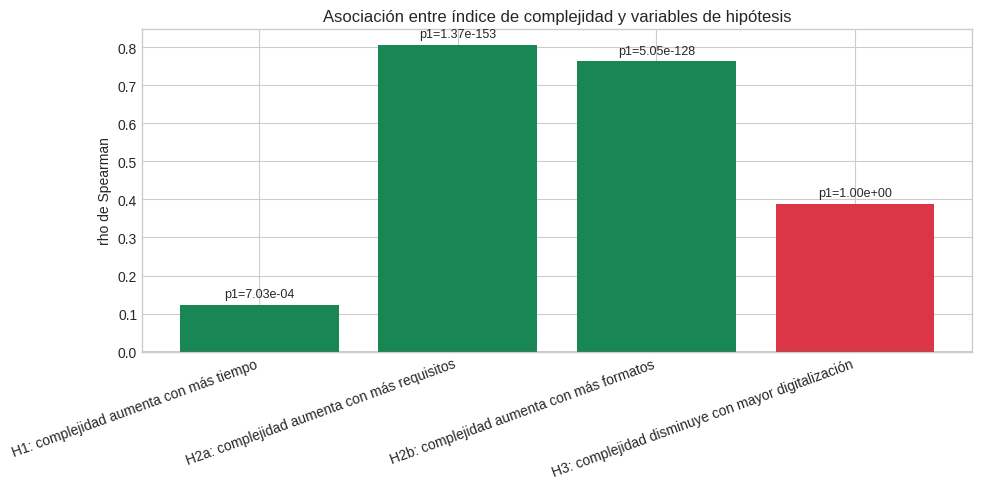

In [9]:
# Gráfico 1: tamaño y signo de asociación para hipótesis
plot_df = hyp.copy()
colors = ['#198754' if d == 'Rechazar H0' else '#dc3545' for d in plot_df['decision_alpha_0_05']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df['hipotesis'], plot_df['rho_spearman'], color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('rho de Spearman')
ax.set_title('Asociación entre índice de complejidad y variables de hipótesis')
ax.set_xticklabels(plot_df['hipotesis'], rotation=20, ha='right')

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(i, row['rho_spearman'] + (0.02 if row['rho_spearman'] >= 0 else -0.05),
            f"p1={row['p_value_one_sided']:.2e}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

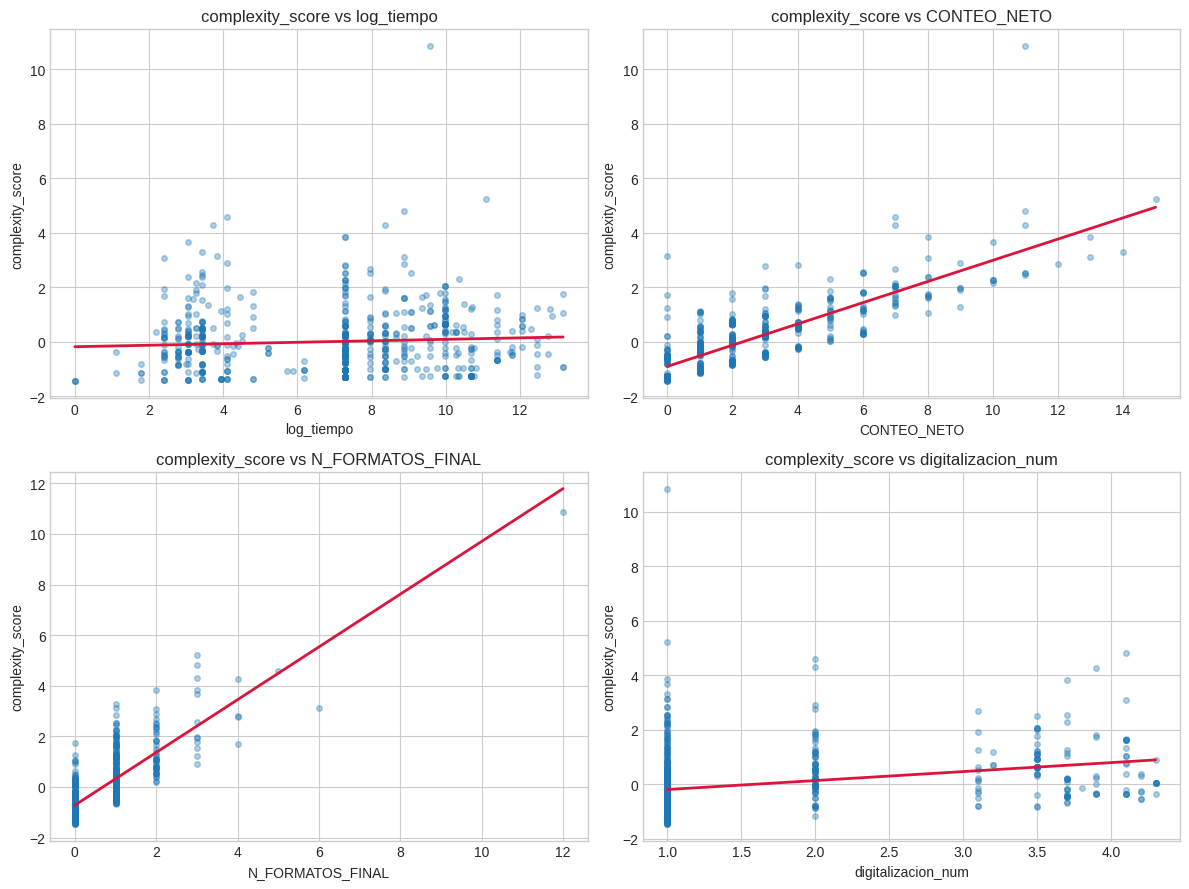

In [10]:
# Gráfico 2: relaciones bivariadas con línea de tendencia
vars_to_plot = ['log_tiempo', 'CONTEO_NETO', 'N_FORMATOS_FINAL', 'digitalizacion_num']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, v in zip(axes, vars_to_plot):
    x = df[v].values
    y = df['complexity_score'].values
    ax.scatter(x, y, alpha=0.35, s=16)

    # línea de tendencia simple
    b1, b0 = np.polyfit(x, y, deg=1)
    xs = np.linspace(np.min(x), np.max(x), 100)
    ax.plot(xs, b1 * xs + b0, color='crimson', linewidth=2)

    ax.set_xlabel(v)
    ax.set_ylabel('complexity_score')
    ax.set_title(f'complexity_score vs {v}')

plt.tight_layout()
plt.show()

## Sensibilidad: regresión robusta de `log_tiempo`
Se estima un modelo OLS con errores robustos HC3 para revisar si, usando `log_tiempo` como proxy simple de complejidad, requisitos y formatos sostienen señal estadística.


In [11]:
ols = smf.ols('log_tiempo ~ CONTEO_NETO + N_FORMATOS_FINAL + digitalizacion_num', data=df).fit(cov_type='HC3')
ols_table = ols.summary2().tables[1][['Coef.', 'P>|z|', '[0.025', '0.975]']]
print('R^2:', round(float(ols.rsquared), 4))
ols_table

R^2: 0.0039


,Coef.,P>|z|,[0.025,0.975]
Intercept,6.672540,8.087404e-194,6.232180,7.112901
CONTEO_NETO,-0.013759,7.843858e-01,-0.112321,0.084803
N_FORMATOS_FINAL,0.041144,7.706227e-01,-0.235440,0.317729
digitalizacion_num,0.168172,1.180818e-01,-0.042728,0.379072


## Modelo para costo (`TraCosto`) con p-values
Modelo logístico robusto (HC3): `TraCosto_bin ~ log_tiempo + CONTEO_NETO + N_FORMATOS_FINAL + digitalizacion_num + Porcentaje_Efectividad + log_visitas_totales + log_visitas_ruts + C(TraPersona)`


In [12]:
logit = smf.logit(
    'TraCosto_bin ~ log_tiempo + CONTEO_NETO + N_FORMATOS_FINAL + digitalizacion_num + '
    'Porcentaje_Efectividad + log_visitas_totales + log_visitas_ruts + C(TraPersona)',
    data=df
).fit(disp=False, cov_type='HC3')

cost_table = logit.summary2().tables[1].copy()
cost_table['OR'] = np.exp(cost_table['Coef.'])
cost_table['significativa_0_05'] = cost_table['P>|z|'] < ALPHA

print('Pseudo R^2:', round(float(logit.prsquared), 4))
cost_table[['Coef.', 'OR', 'P>|z|', '[0.025', '0.975]', 'significativa_0_05']]

Pseudo R^2: 0.0673


,Coef.,OR,P>|z|,[0.025,0.975],significativa_0_05
Intercept,0.943827,2.569798,0.161423,-0.377223,2.264877,False
C(TraPersona)[T.Empresarial],-0.105327,0.900031,0.819785,-1.011456,0.800803,False
C(TraPersona)[T.Social],-0.011514,0.988552,0.955229,-0.413487,0.390459,False
log_tiempo,-0.024067,0.976221,0.461763,-0.088161,0.040027,False
CONTEO_NETO,0.283130,1.327278,0.000006,0.160078,0.406182,True
N_FORMATOS_FINAL,-0.128531,0.879386,0.222800,-0.335171,0.078108,False
digitalizacion_num,0.258034,1.294383,0.005376,0.076348,0.439720,True
Porcentaje_Efectividad,0.000580,1.000580,0.798318,-0.003866,0.005025,False
log_visitas_totales,-0.100624,0.904273,0.248637,-0.271574,0.070326,False
log_visitas_ruts,-0.027649,0.972730,0.675118,-0.156943,0.101644,False


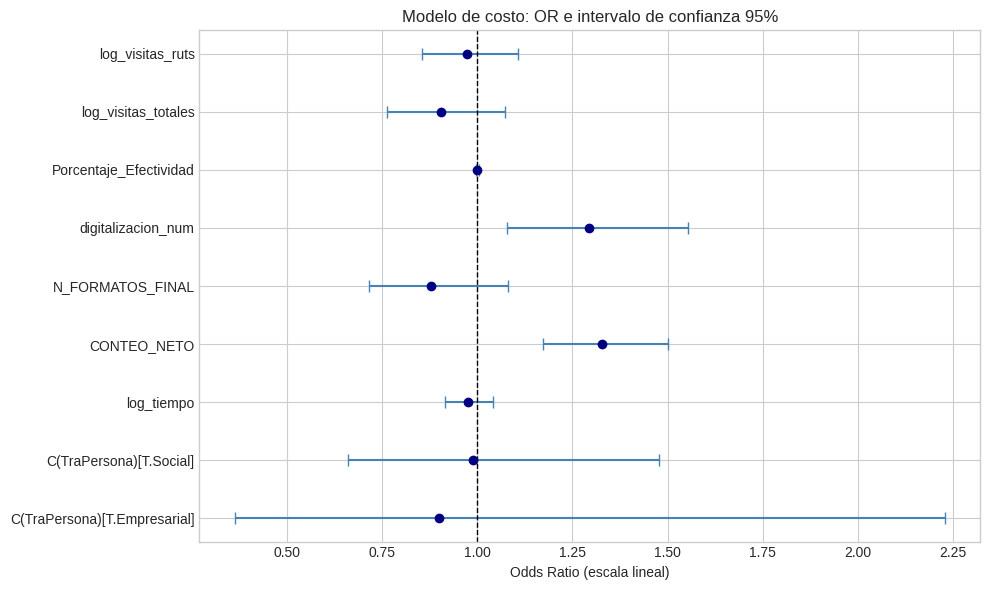

In [13]:
# Gráfico 3: odds ratios (sin intercepto)
plot_cost = cost_table.drop(index='Intercept', errors='ignore').copy()
plot_cost['or_low'] = np.exp(plot_cost['[0.025'])
plot_cost['or_high'] = np.exp(plot_cost['0.975]'])

fig, ax = plt.subplots(figsize=(10, 6))
ypos = np.arange(len(plot_cost))

ax.errorbar(
    plot_cost['OR'],
    ypos,
    xerr=[plot_cost['OR'] - plot_cost['or_low'], plot_cost['or_high'] - plot_cost['OR']],
    fmt='o', color='navy', ecolor='steelblue', capsize=4
)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels(plot_cost.index)
ax.set_xlabel('Odds Ratio (escala lineal)')
ax.set_title('Modelo de costo: OR e intervalo de confianza 95%')

plt.tight_layout()
plt.show()

## Explicación simple: ¿se rechazan hipótesis nulas?

Regla simple: si `p-value < 0.05`, **rechazamos H0**; si `p-value >= 0.05`, **no rechazamos H0**.

Con este análisis:
- Para H1, H2a y H2b, el p-value fue menor a 0.05, por lo que **sí se rechaza H0** y los datos apoyan esas relaciones en el sentido esperado.
- Para H3, el p-value fue significativo pero con signo contrario al esperado, por lo que **no se respalda la hipótesis en el sentido planteado** y conviene revisar la codificación/semántica de `nivel_digitalizacion`.

En costo (`TraCosto`), las variables con p-value menor a 0.05 se interpretan como asociadas al costo en el modelo (no implica causalidad).


In [14]:
# Guardar resultados en outputs para trazabilidad
out = Path.cwd() / 'outputs'
out.mkdir(exist_ok=True)

hyp.to_csv(out / 'notebook_hypothesis_results.csv', index=False)
loadings.to_frame('loading_pc1').to_csv(out / 'notebook_pca_loadings.csv')
cost_table.to_csv(out / 'notebook_cost_logit_table.csv')

print('Archivos escritos en:', out)
print(sorted([p.name for p in out.glob('notebook_*')]))

Archivos escritos en: /home/uplaph/Projects/Tramites-y-servicios/deep-analysis/outputs
['notebook_cost_logit_table.csv', 'notebook_hypothesis_results.csv', 'notebook_pca_loadings.csv']
